In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style('whitegrid')

In [5]:
# Carregar os datasets CSV da pasta 'data'
customers = pd.read_csv('../data/olist_customers_dataset.csv')
geolocation = pd.read_csv('../data/olist_geolocation_dataset.csv')
order_items = pd.read_csv('../data/olist_order_items_dataset.csv')
order_payments = pd.read_csv('../data/olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('../data/olist_order_reviews_dataset.csv')
orders = pd.read_csv('../data/olist_orders_dataset.csv')
products = pd.read_csv('../data/olist_products_dataset.csv')
sellers = pd.read_csv('../data/olist_sellers_dataset.csv')
product_translation = pd.read_csv('../data/product_category_name_translation.csv')

In [6]:
data = {
    "customers" : customers,
    "geolocation" : geolocation,
    "order_items" : order_items,
    "order_payments" : order_payments,
    "order_reviews" : order_reviews,
    "orders" : orders,
    "products" : products,
    "sellers" : sellers,
    "product_translation" : product_translation
}

In [6]:
for c, v in data.items():
    print(c, v.shape)

customers (99441, 5)
geolocation (1000163, 5)
order_items (112650, 7)
order_payments (103886, 5)
order_reviews (99224, 7)
orders (99441, 8)
products (32951, 9)
sellers (3095, 4)
product_translation (71, 2)


In [7]:
for c, v in data.items():
    print(c, v.isnull().sum().sum())

customers 0
geolocation 0
order_items 0
order_payments 0
order_reviews 145903
orders 4908
products 2448
sellers 0
product_translation 0


In [ ]:
# Não será preciso retirar as duplicatas da geolocation, visto que o mesmo CEP pode abranger
# diferentes lat/lng. É bem comum, pois o CEP representa uma região, não um ponto exato.
for c, v in data.items():
    print(c, v.duplicated().sum().sum())

customers 0
geolocation 261831
order_items 0
order_payments 0
order_reviews 0
orders 0
products 0
sellers 0
product_translation 0


In [13]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [14]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [ ]:
#Não será preciso realizar a tratativa desses dados, ou seja, não precisa retirar os valores nulos.
order_reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [21]:
order_reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [28]:
order_reviews["review_score"].value_counts().sort_values(ascending=False)

review_score
5    57328
4    19142
1    11424
3     8179
2     3151
Name: count, dtype: int64

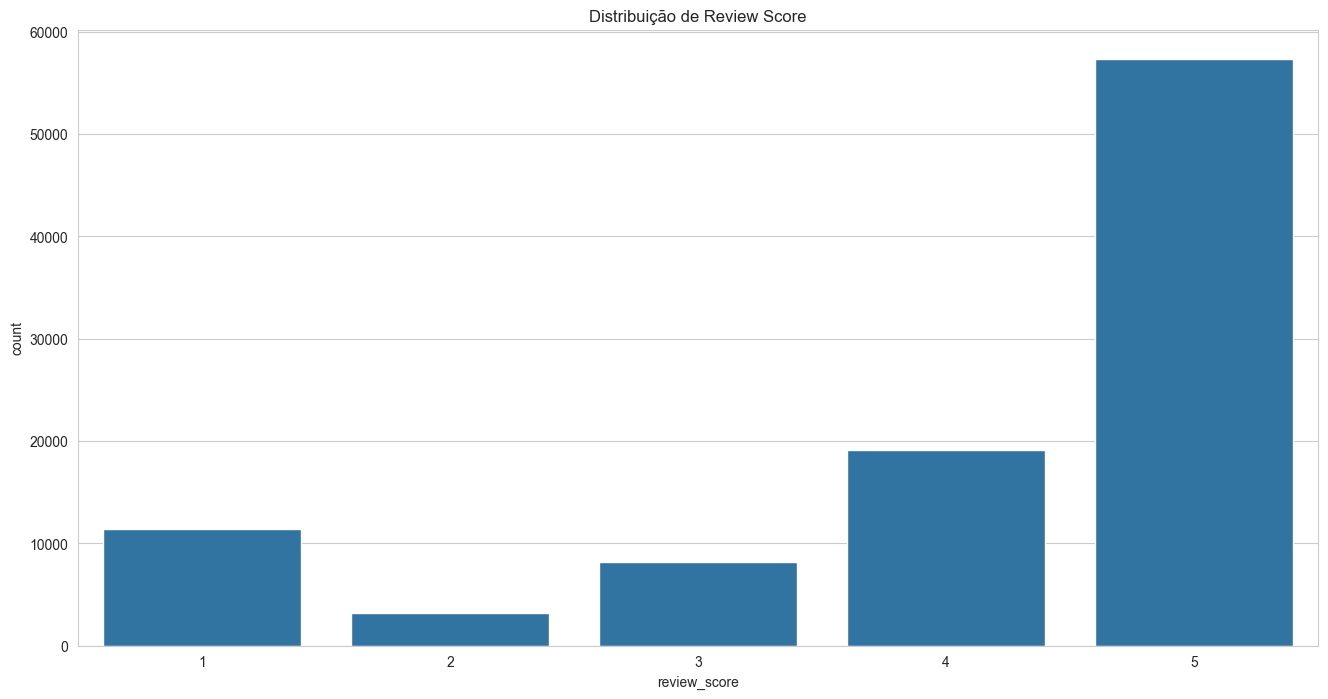

In [32]:
plt.figure(figsize=(16, 8))
sns.countplot(data=order_reviews, x="review_score", order=sorted(order_reviews["review_score"].unique()))
plt.title("Distribuição de Review Score")
plt.show()

In [9]:
import nltk
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('portuguese'))

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\vitor\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vitor\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
# Filtrar reviews com títulos não nulos para text mining
textmining = order_reviews.dropna(subset=['review_comment_title'])

In [15]:
# Função de pré-processamento: tokenizar, lowercase, remover stopwords e não-alfabéticos
def preprocess_text(text):
    tokens = nltk.word_tokenize(text.lower())
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return tokens

# Aplicar tokenização aos títulos
textmining['tokens_title'] = textmining['review_comment_title'].apply(preprocess_text)

Top 20 palavras mais frequentes:
[('recomendo', 2067), ('bom', 1313), ('produto', 1288), ('super', 896), ('ótimo', 725), ('excelente', 665), ('entrega', 529), ('otimo', 368), ('recebi', 288), ('boa', 272), ('ótima', 215), ('tudo', 192), ('recomendado', 176), ('entregue', 174), ('ok', 156), ('prazo', 150), ('compra', 149), ('loja', 132), ('rápida', 132), ('perfeito', 131)]


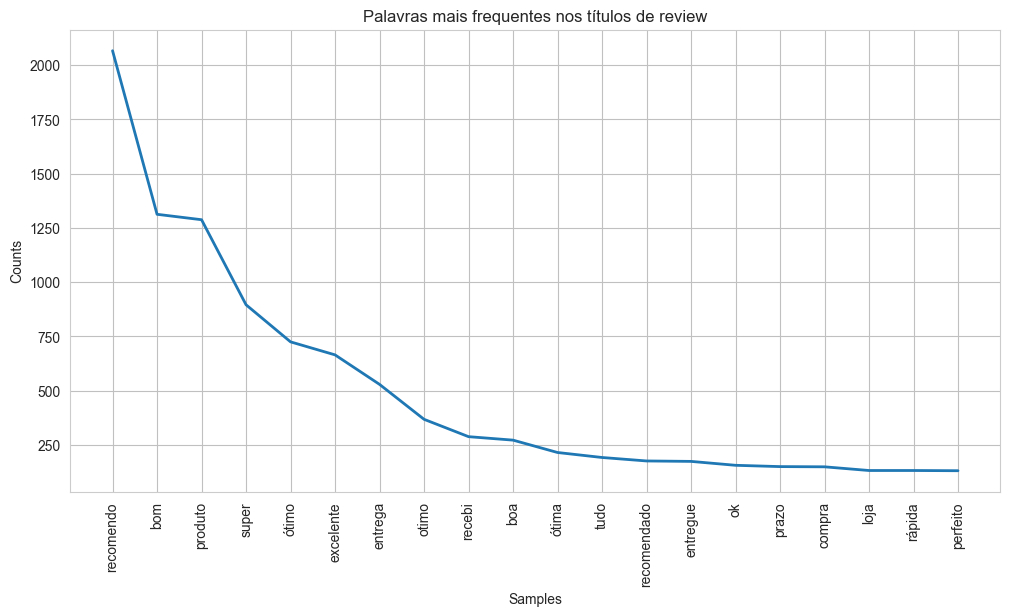

In [20]:
# Coletar todos os tokens em uma lista
all_tokens = [token for sublist in textmining['tokens_title'] for token in sublist]

# Calcular frequência das palavras
freq_dist = nltk.FreqDist(all_tokens)

# Exibir top 20 palavras mais frequentes
print("Top 20 palavras mais frequentes:")
print(freq_dist.most_common(20))

# Plotar distribuição
plt.figure(figsize=(12, 6))
freq_dist.plot(20, title="Palavras mais frequentes nos títulos de review")
plt.show()

Top 20 palavras mais frequentes nos comentários:
[('produto', 18344), ('prazo', 8410), ('entrega', 6486), ('antes', 5619), ('chegou', 5535), ('recebi', 5262), ('bom', 4592), ('recomendo', 4269), ('entregue', 3769), ('veio', 3276), ('bem', 3102), ('qualidade', 2755), ('comprei', 2750), ('loja', 2393), ('ainda', 2328), ('tudo', 2322), ('compra', 2191), ('gostei', 1884), ('ótimo', 1812), ('excelente', 1797)]


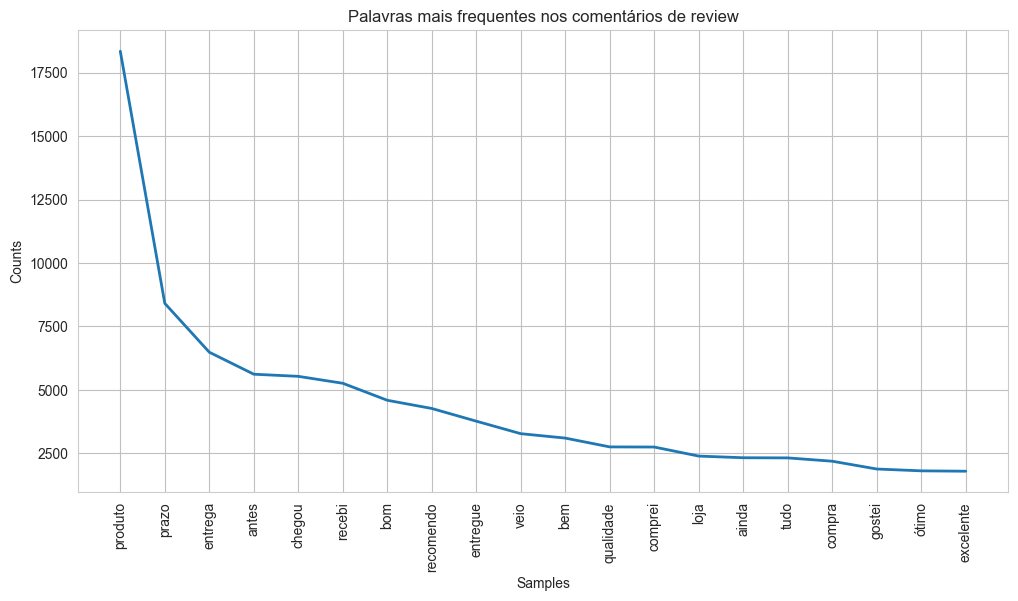

In [21]:
# Análise de comentários (review_comment_message)
textmining_messages = order_reviews.dropna(subset=['review_comment_message'])

# Aplicar pré-processamento aos comentários
textmining_messages['tokens_message'] = textmining_messages['review_comment_message'].apply(preprocess_text)

# Coletar todos os tokens dos comentários
all_tokens_messages = [token for sublist in textmining_messages['tokens_message'] for token in sublist]

# Frequência das palavras nos comentários
freq_dist_messages = nltk.FreqDist(all_tokens_messages)

# Top 20 palavras mais frequentes nos comentários
print("Top 20 palavras mais frequentes nos comentários:")
print(freq_dist_messages.most_common(20))

# Plotar distribuição
plt.figure(figsize=(12, 6))
freq_dist_messages.plot(20, title="Palavras mais frequentes nos comentários de review")
plt.show()